In [117]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Question 3

## Load Class Names

In [118]:
dataset_path = "dataset"
breeds = sorted(os.listdir(dataset_path))
breeds = [b for b in breeds if os.path.isdir(os.path.join(dataset_path, b))]

class_ids = {label: i for i, label in enumerate(breeds)}
class_ids

{'Beagle': 0,
 'Boxer': 1,
 'Bulldog': 2,
 'Dachshund': 3,
 'German_Shepherd': 4,
 'Golden_Retriever': 5,
 'Labrador_Retriever': 6,
 'Poodle': 7,
 'Rottweiler': 8,
 'Yorkshire_Terrier': 9}

## Display Sample Image

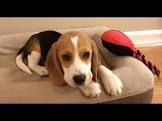

In [119]:
sample_breed = breeds[0]
sample_images = os.listdir(os.path.join(dataset_path, sample_breed))
sample_path = os.path.join(dataset_path, sample_breed, sample_images[0])
sample_img = Image.open(sample_path)
sample_img

## Load All Images

Loading all images as RGB (3 channels), resizing to 64x64. Targets are encoded as integers based on class id.

In [120]:
image_size = (64, 64)

inputs = []
targets = []

for label in breeds:
    breed_path = os.path.join(dataset_path, label)
    for img_name in os.listdir(breed_path):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(breed_path, img_name)
            img = Image.open(img_path).convert('RGB').resize(image_size)
            inputs.append(img)
            targets.append(class_ids[label])

inputs = np.float32(inputs)
targets = np.int32(targets)

inputs.shape, targets.shape

((967, 64, 64, 3), (967,))

## Plot Target Distribution

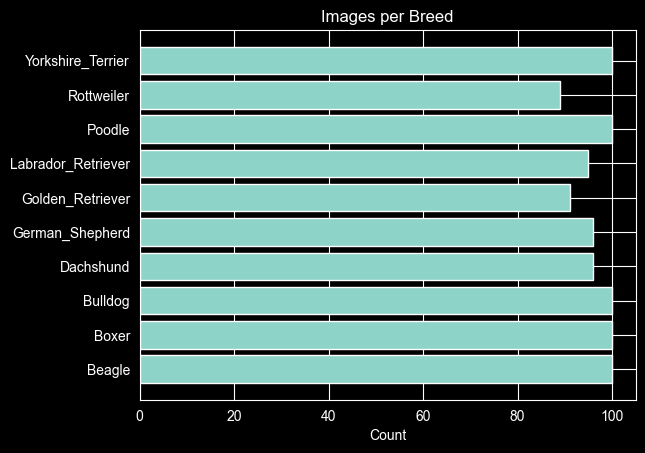

In [121]:
target_counts = np.unique(targets, return_counts=True)
plt.barh(breeds, target_counts[1])
plt.xlabel('Count')
plt.title('Images per Breed')
plt.show()

## Set Seeds for Reproducibility

In [122]:
seed = 0

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

## Split into Train-Test with Stratify

In [123]:
x_train, x_test, y_train, y_test = train_test_split(
    inputs,
    targets,
    test_size=0.2,
    stratify=targets,
    random_state=seed
)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((773, 64, 64, 3), (773,), (194, 64, 64, 3), (194,))

## Preprocess Dataset

Normalize inputs to [0.0, 1.0] by dividing by 255.0. One-hot encode targets for softmax activation.

In [124]:
x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = np.eye(len(breeds))[y_train]
y_test = np.eye(len(breeds))[y_test]

y_train.shape, y_test.shape

((773, 10), (194, 10))

# Question 4

## Building Multi-Layer Perceptron

Input: (64, 64, 3) flattened into a vector of 12288.
Output: 10 (number of classes).

In [125]:
input_size = x_train.shape[1:]
output_size = len(breeds)

mlp = keras.Sequential([
    layers.Input(shape=input_size),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(output_size, activation='softmax')
], name='MLP')

mlp.summary()

print()
print("Architecture Analysis:")
print("Layer 1 - Flatten: Input (64, 64, 3) -> Output (12288,)")
print("Layer 2 - Dense: Input 12288 -> Output 128, Activation: ReLU")
print("Layer 3 - Dense: Input 128 -> Output 64, Activation: ReLU")
print("Layer 4 - Dense: Input 64 -> Output", output_size, ", Activation: Softmax")

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,898 (6.03 MB)

 Trainable params: 1,581,898 (6.03 MB)

 Non-trainable params: 0 (0.00 B)


Architecture Analysis:
Layer 1 - Flatten: Input (64, 64, 3) -> Output (12288,)
Layer 2 - Dense: Input 12288 -> Output 128, Activation: ReLU
Layer 3 - Dense: Input 128 -> Output 64, Activation: ReLU
Layer 4 - Dense: Input 64 -> Output 10 , Activation: Softmax


# Question 5

## Training MLP

* Optimizer: Adam
* Learning Rate: 0.001
* Loss Function: Categorical Cross-Entropy
* Batch Size: 32
* Epochs: 30

In [126]:
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [127]:
mlp_history = mlp.fit(
    x_train,
    y_train,
    batch_size=32,
    epochs=30,
    validation_data=(x_test, y_test)
)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1397 - loss: 3.5614 - val_accuracy: 0.3351 - val_loss: 2.3700
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3027 - loss: 2.0002 - val_accuracy: 0.3660 - val_loss: 1.9628
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4398 - loss: 1.6573 - val_accuracy: 0.4227 - val_loss: 1.6700
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5446 - loss: 1.3969 - val_accuracy: 0.5876 - val_loss: 1.4615
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 1.1338 - val_accuracy: 0.6186 - val_loss: 1.2921
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7257 - loss: 0.9520 - val_accuracy: 0.7113 - val_loss: 1.1813
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8047 - loss: 0.7921 - val_accuracy: 0.6753 - val_loss: 1.1595
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8266 - loss: 0.7053 - val_accuracy: 0.7216 - val_loss:

# Question 6

## MLP Performance: Train-Test Loss

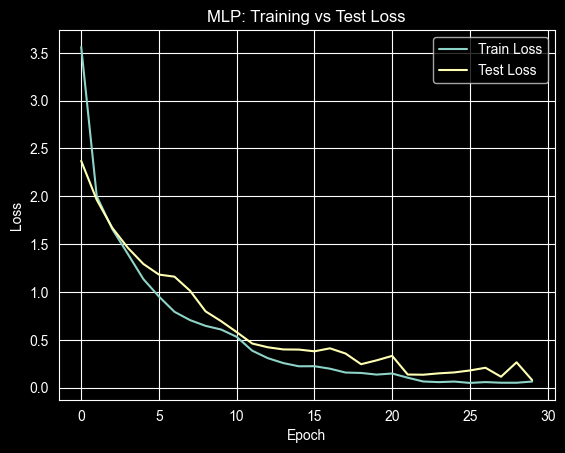

In [128]:
plt.figure()
plt.plot(mlp_history.history['loss'], label='Train Loss')
plt.plot(mlp_history.history['val_loss'], label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP: Training vs Test Loss')
plt.legend()
plt.grid(True)
plt.show()

## MLP Performance: Train-Test Accuracy

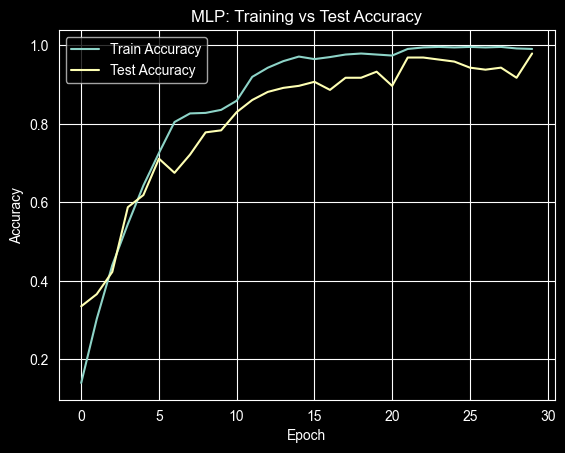

In [129]:
plt.figure()
plt.plot(mlp_history.history['accuracy'], label='Train Accuracy')
plt.plot(mlp_history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MLP: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()